This is the collected notebook to produce a figure comparing Q-learning, DQN and PPO (Include DDPG if possible)
Figure color and design is to be determined later. Structure is already set.

In [ ]:
#Packages and common classes and functions
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym
from gymnasium import spaces
from gymnasium.wrappers import TimeLimit
import pandas as pd
import os as os

rd.seed(42)

class Position:
    #Class to represent a position on a grid
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __add__(self, other):
        return Position(self.x + other.x, self.y + other.y)

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
def avg_dist_on_grid(size):
    #Calculates the average distance between two random points on a grid
    iterations = 1000000
    manhattan_dist = []
    euclidean_dist = []

    for i in tqdm(range(iterations)):
        x_loot = rd.randint(0, size[0])
        y_loot = rd.randint(0, size[1])
        x_pos = rd.randint(0, size[0])
        y_pos = rd.randint(0, size[1])
        x = abs(x_loot - x_pos)
        y = abs(y_loot - y_pos)
        manhattan_dist.append(x+y)
        euclidean_dist.append(np.sqrt(x**2 + y**2))

    manhattan_avg = sum(manhattan_dist)/len(manhattan_dist)
    euclidean_avg = sum(euclidean_dist)/len(euclidean_dist)

    return manhattan_avg, euclidean_avg

def steps_per_episode_plotter(steps_per_episode, benchmark_dist, legend=True):
    # Plot the steps per episode
    plt.plot(range(len(steps_per_episode)), steps_per_episode, color='blue', label='Steps per Episode')

    # Rolling average for 10 episodes
    plt.plot(range(9, len(steps_per_episode)),  # Starts at episode 10
         np.convolve(steps_per_episode, np.ones(10)/10, mode='valid'),
         color='orange', label='Rolling Avg (10 episodes)')

    # Rolling average for 100 episodes
    plt.plot(range(99, len(steps_per_episode)),  # Starts at episode 100
         np.convolve(steps_per_episode, np.ones(100)/100, mode='valid'),
         color='green', label='Rolling Avg (100 episodes)')

    # Rolling average for 1000 episodes
    plt.plot(range(999, len(steps_per_episode)),  # Starts at episode 1000
         np.convolve(steps_per_episode, np.ones(1000)/1000, mode='valid'),
         color='red', label='Rolling Avg (1000 episodes)')

    # Labels and title
    plt.xlabel('Episode')
    plt.ylabel('Steps Taken')
    plt.ylim(0, 100)
    plt.axhline(benchmark_dist, color='black', linewidth=1, linestyle='--', label=f'Optimal policy - num_steps = {benchmark_dist}')
    plt.axhline(np.mean(steps_per_episode[-100:]), color='black', linewidth=1, linestyle='--', label=f'Trained policy - num_steps = {np.mean(steps_per_episode[-100:])}$\pm${np.std(steps_per_episode[-100:]):.2f}')

    if legend == True:
        plt.legend()

    # Show the plot
    plt.show()

def plot_q_matrix_with_trajectory_discrete(q_matrix, loot_x, loot_y, start_x, start_y):
    # Extract the Q-values for the given loot position
    q_matrix_with_loot = q_matrix[:, :, loot_x, loot_y, :]
    direction_matrix = np.argmax(q_matrix_with_loot, axis=2)

    # Define the direction vectors for actions. Note reserve y, x index for matrix indexing
    direction_vectors = {
        0: (1, 0),   # Up
        1: (-1, 0),  # Down
        2: (0, 1),   # Right
        3: (0, -1)   # Left
    }

    # Create grid for quiver plot, centered arrows
    x, y = np.meshgrid(np.arange(direction_matrix.shape[1]), np.arange(direction_matrix.shape[0]))
    x = x + 0.5
    y = y + 0.5

    # Create arrays for arrow directions
    u = np.zeros_like(direction_matrix, dtype=float)
    v = np.zeros_like(direction_matrix, dtype=float)

    for i in range(direction_matrix.shape[0]):
        for j in range(direction_matrix.shape[1]):
            direction = direction_matrix[i, j]
            u[i, j], v[i, j] = direction_vectors[direction]

    # Plot quiver (policy directions)
    plt.figure(figsize=(5, 5))
    plt.quiver(x, y, u, v)

    # Plot loot position as a red square
    plt.gca().add_patch(Rectangle((loot_x, loot_y), 1, 1, edgecolor='red', facecolor='grey', lw=2))

    # Simulate a trajectory starting at (start_x, start_y)
    traj_x, traj_y = [start_x + 0.5], [start_y + 0.5]  # Start the trajectory at the center of the starting cell
    current_x, current_y = start_x, start_y

    for _ in range(20):  # Limit the number of moves in the trajectory to avoid infinite loops
        direction = direction_matrix[current_y, current_x]  # Note y, x because of the way the matrix is indexed
        move_x, move_y = direction_vectors[direction]
        new_x = current_x + move_x
        new_y = current_y + move_y

        # If the new position is out of bounds or we reach the loot, stop the trajectory
        if new_x < 0 or new_x >= q_matrix.shape[0] or new_y < 0 or new_y >= q_matrix.shape[1]:
            print('Trajectory out of bounds')
            break
        if new_x == loot_x and new_y == loot_y:
            print('Trajectory reached loot')
            break

        # Add the new position to the trajectory
        traj_x.append(new_x + 0.5)  # Center the trajectory points
        traj_y.append(new_y + 0.5)

        current_x, current_y = new_x, new_y

    # Plot the trajectory on top of the arrows
    plt.plot(traj_x, traj_y, marker='o', color='blue', markersize=8, label="Trajectory")

    # Adjust grid and plot settings
    #plt.gca().invert_yaxis()  # Invert y-axis for proper grid layout
    plt.gca().grid(True)
    plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1))
    plt.gca().yaxis.set_major_locator(plt.MultipleLocator(1))
    plt.title(f"Sample policy with trajectory from ({start_x}, {start_y}) and loot at ({loot_x}, {loot_y})")
    plt.legend()
    plt.show()




<>:82: SyntaxWarning: invalid escape sequence '\p'
<>:82: SyntaxWarning: invalid escape sequence '\p'
C:\Users\micha\AppData\Local\Temp\ipykernel_1776\2029882069.py:82: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(np.mean(steps_per_episode[-100:]), color='black', linewidth=1, linestyle='--', label=f'Trained policy - num_steps = {np.mean(steps_per_episode[-100:])}$\pm${np.std(steps_per_episode[-100:]):.2f}')


In [2]:
#Q-learning classes and functions
class QLAgent:
    def __init__(self, env, pos, name='Agent', gamma=0.9):
        self.env = env
        self.pos = pos
        self.actions = [Position(0, 1), Position(0, -1), Position(1, 0), Position(-1, 0)]        
        self.nstates = len(self.env.states)
        self.nactions = len(self.actions)
        self.history = []
        self.last_history = None
        self.gamma = gamma  # Discount factor

    def init_Q(self, Q_noise=0.1):    
        self.Q = np.ones((self.nstates, self.nactions)) * 0.5  # Initialize Q-table with moderate values
        self.Q_noise = Q_noise

    def set_Q_noise(self, Q_noise):
        self.Q_noise = Q_noise

    def __repr__(self):
        return f'{self.__class__.__name__} at position {self.pos}'

    def move(self, action_idx, state_index):
        self.history.append((state_index, action_idx))

        direction = self.actions[action_idx]
        new_pos = self.pos + direction

        if self.env.is_valid(new_pos):
            self.pos = new_pos

    def get_action(self, state_index):
        """Choose action based on epsilon-greedy strategy using Q-values."""
        return np.argmax(self.Q[state_index] + np.random.randn(self.nactions) * self.Q_noise)

    def update_Q(self, reward):
        """Update Q-values using gamma for discounted future rewards."""
        future_reward = reward
        # Traverse the agent's history in reverse order
        for state, action in reversed(self.history):
            self.Q[state][action] = (self.Q[state][action] * 20 + future_reward) / 21  # Smoothing the update
            future_reward *= self.gamma  # Discount the future rewards

        self.history.clear()  # Clear the history after updating Q-values

class QLEnvironment:
    def __init__(self, size):
        self.width = size[0]
        self.height = size[1]
        self.agents = []
        self.states = self.get_state_list(len(self.agents))
        self.loot = Position(np.random.randint(0, self.width), np.random.randint(0, self.height))
        self.num_games = 0
        self.num_moves_in_game = 0
        self.length_of_games = []
        self.loot_dym = 'dynamic'

    def reset(self):
        self.num_games = 0
        self.num_moves_in_game = 0
        self.length_of_games = []
    
        # Randomize loot position
        self.loot = Position(np.random.randint(0, self.width), np.random.randint(0, self.height))
    
        # Randomize agent positions
        for agent in self.agents:
            agent.pos = Position(np.random.randint(0, self.width), np.random.randint(0, self.height))
            agent.history = []


    def is_valid(self, pos):
        return 0 <= pos.x < self.width and 0 <= pos.y < self.height

    def add_agent(self, agent):
        self.agents.append(agent)
        self.states = self.get_state_list(len(self.agents))
        agent.nstates = len(self.states)
        agent.init_Q()

    def get_state_list(self, n_agents=2):
        states = []
        if n_agents == 1:
            for p1x in range(self.width):
                for p1y in range(self.height):
                    for lootx in range(self.width):
                        for looty in range(self.height):
                            states.append([p1x, p1y, lootx, looty])
        elif n_agents == 2:
            for p1x in range(self.width):
                for p1y in range(self.height):
                    for p2x in range(self.width):
                        for p2y in range(self.height):
                            for lootx in range(self.width):
                                for looty in range(self.height):
                                    states.append([p1x, p1y, p2x, p2y, lootx, looty])
        return np.array(states)

    def get_state_index(self, state_short_name):
        idx = np.argmax(np.sum(self.states == np.array(state_short_name), axis=1))
        return idx

    def get_state(self):
        state_short_name = [0, 0] * len(self.agents) + [self.loot.x, self.loot.y]
        state = np.zeros((self.height, self.width))

        for i, agent in enumerate(self.agents):
            state[agent.pos.y][agent.pos.x] = 1
            state_short_name[2*i] = agent.pos.x
            state_short_name[2*i+1] = agent.pos.y

        state[self.loot.y][self.loot.x] = 2
        state_index = self.get_state_index(state_short_name)
        return state, state_short_name, state_index

    def visualize(self):
        state, short_name, state_index = self.get_state()
        plt.imshow(state, cmap='gray')
        plt.title(f'State index: {state_index}, State short name: {short_name}')
        plt.show()

    def move_loot(self):
        self.loot = Position(np.random.randint(self.width), np.random.randint(self.height))

    def set_loot_dym(self, loot_dym='dynamic'):
        self.loot_dym = loot_dym

    def step(self):
        state, short_name, state_index = self.get_state()
        for agent in self.agents:
            action = agent.get_action(state_index)
            agent.move(action, state_index)
        
        winners = []
        for agent in self.agents:
            if agent.pos == self.loot:
                winners.append(agent)

        if winners:
            for agent in self.agents:
                reward = 1 if agent in winners else 0
                agent.update_Q(reward)

            if self.loot_dym == 'dynamic':
                self.move_loot()

            self.num_games += 1
            self.length_of_games.append(self.num_moves_in_game)
            self.num_moves_in_game = 0
        else:
            self.num_moves_in_game += 1

def train_q_learning_agent(env, agent, episodes=1000):
    steps_per_episode = []
    
    for episode in tqdm(range(episodes)):
        # Reset the environment for each episode
        env.reset()
        
        total_steps = 0
        done = False
        
        while not done:
            # Step the environment
            env.step()
            total_steps += 1
            
            # If the game is over (i.e., the loot was found), break the loop
            if env.num_moves_in_game == 0:  # Loot was found, game resets in step
                done = True
        
        steps_per_episode.append(total_steps)
    
    return steps_per_episode, agent.Q.reshape(8, 8, 8, 8, 4)




In [3]:
#Deep Q-Learning classes and functions
class DQNEnvironment:
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.states = [[0] * width for _ in range(height)]
        self.agents = []
        self.loot = Position(rd.randint(0, width-1), rd.randint(0, height-1))
        self.step_num = 0

    def add_agent(self, agent):
        self.agents.append(agent)

    def get_state(self, agent_pos):
        # Return a vector representing the agent's position and the loot's position
        return np.array([agent_pos.x, agent_pos.y, self.loot.x, self.loot.y])
    
    def visualize(self):
        short_name = self.get_state()
        state = torch.zeros((self.width, self.height))
        state[short_name[0], short_name[1]] = 1
        state[short_name[2], short_name[3]] = 2
        
        plt.imshow(state, cmap='gray')
        # plt.title(f'State index: {state_index}, State short name: {short_name}')
        plt.show()

    def reset(self):
        # Reset loot and agents to random positions
        self.loot = Position(rd.randint(0, self.width - 1), rd.randint(0, self.height - 1))
        for agent in self.agents:
            agent.pos = Position(rd.randint(0, self.width - 1), rd.randint(0, self.height - 1))

    def step(self, agent, action):
        self.step_num += 1
        # Apply action to agent
        next_pos = Position(agent.pos.x + action.x, agent.pos.y + action.y)
        next_pos.x = max(0, min(next_pos.x, self.width - 1))
        next_pos.y = max(0, min(next_pos.y, self.height - 1))
        
        dist_to_loot = np.linalg.norm([next_pos.x - self.loot.x, next_pos.y - self.loot.y])


        reward = -dist_to_loot  # Default negative reward to encourage faster looting
        done = False
        
        if next_pos.x == self.loot.x and next_pos.y == self.loot.y:
            reward = 1000  # Reward for reaching loot
            done = True

        agent.pos = next_pos
        return self.get_state(agent.pos), reward, done

# Define the DQN class
class DQN(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(n_inputs, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, n_outputs)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

# Define the DQNAgent class
class DQNAgent:
    def __init__(self, env, pos, name='Agent', gamma=0.9999, epsilon=1, epsilon_min=0.01, lr=0.0005): #epsilon_decay=0.95
        self.env = env
        self.pos = pos
        self.name = name
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.epsilon_min = epsilon_min
        #self.epsilon_decay = epsilon_decay
        self.learning_rate = lr
        self.actions = [Position(0, 1), Position(0, -1), Position(1, 0), Position(-1, 0)]        
        self.n_inputs = 4  # My position (x, y) + Loot position (x, y)
        self.n_outputs = len(self.actions)  # 4 possible actions: up, down, left, right
        self.memory = deque(maxlen=500)
        self.model = DQN(self.n_inputs, self.n_outputs)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return rd.choice(self.actions)  # Exploration
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        q_values = self.model(state_tensor)
        action_index = torch.argmax(q_values).item()  # Exploitation
        return self.actions[action_index]

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def __repr__(self):
        return f'{self.__class__.__name__} at position {self.pos}'

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = rd.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
            
            # Compute the target value
            target = reward
            if not done:
                target = reward + self.gamma * torch.max(self.model(next_state_tensor)).item()
            
            # Get the current predicted Q-values
            target_f = self.model(state_tensor).detach().clone()  # Detach to avoid in-place operation errors
            action_index = self.actions.index(action)
            target_f[0][action_index] = target
            
            # Forward pass and compute loss
            current_q_values = self.model(state_tensor)
            self.optimizer.zero_grad()
            loss = F.mse_loss(current_q_values, target_f)
            loss.backward()
            self.optimizer.step()

        self.memory = deque(maxlen=500)

    def train(self, episodes, batch_size):
        self.episodes = episodes
        #self.epsilon_decay = (1 - self.epsilon_min) / (self.episodes*0.8)
        self.epsilon = 0.2
        saved_rewards = []
        saved_num_steps = []
        for e in range(episodes):
            state = self.env.get_state(self.pos)
            done = False
            total_reward = 0
            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(self, action)
                self.remember(state, action, reward, next_state, done)
                state = next_state
                if self.env.step_num > 1000:
                    print(f"Episode {e}/{episodes}: Reached step limit, resetting...")
                    done = True

                total_reward += reward
            #total_reward = np.clip(total_reward, -1000, 100)
            saved_rewards.append(total_reward)
            print(f'Episode: {e}/{episodes}, Total Reward: {total_reward}, Epsilon: {self.epsilon:.2f}, num_steps: {self.env.step_num}')
            
                    # Decay epsilon for the epsilon-greedy strategy
            #if self.epsilon > self.epsilon_min:
            #    self.epsilon -= self.epsilon_decay
            

            self.replay(batch_size)
            saved_num_steps.append(self.env.step_num)
            self.env.step_num = 0
            self.env.reset()
        return saved_rewards, saved_num_steps

def generate_q_matrix(agent, env):
    # Initialize an empty Q-matrix. Each entry corresponds to Q-values for each state-action pair.
    q_matrix = np.zeros((env.width, env.height, env.width, env.height, len(agent.actions)))

    # Loop through all possible positions of the agent and loot
    for agent_x in range(env.width):
        for agent_y in range(env.height):
            for loot_x in range(env.width):
                for loot_y in range(env.height):
                    # Define the state as the combination of the agent's and loot's position
                    state = np.array([agent_x, agent_y, loot_x, loot_y])
                    state_tensor = torch.FloatTensor(state).unsqueeze(0)
                    
                    # Get the Q-values for the current state
                    q_values = agent.model(state_tensor).detach().numpy().squeeze()
                    
                    # Store the Q-values in the Q-matrix
                    q_matrix[agent_x, agent_y, loot_x, loot_y, :] = q_values

    return q_matrix


#lr=0.000005, episode=100000, batch_size=16, epsilon static at 0.2 converges nicely after ~1 hour.

In [4]:
#PPO classes and functions

class PPOEnvironment(gym.Env):
    def __init__(self, size, speed=1, max_steps=500):
        super(PPOEnvironment, self).__init__()
        self.size = size
        self.speed = speed
        # Define the state space: Agent's position and Loot's position
        self.observation_space = spaces.Box(low=0, high=self.size[0], shape=(4,), dtype=np.float32)
        
        # Define the action space: Continuous movement in both x and y
        self.action_space = spaces.Box(low=-self.speed, high=self.speed, shape=(2,), dtype=np.float32)
        
        # Initialize agent and loot positions
        self.agent_pos = [rd.randint(0, self.size[0]), rd.randint(0, self.size[1])]
        self.loot_pos = [rd.randint(0, self.size[0]), rd.randint(0, self.size[1])]
        self.step_count = 0
        self.max_steps = max_steps 

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        
        # Reset agent and loot positions
        self.agent_pos = [rd.randint(0, self.size[0]), rd.randint(0, self.size[1])]
        self.loot_pos = [rd.randint(0, self.size[0]), rd.randint(0, self.size[1])]
        self.step_count = 0  # Reset step count when the episode starts
        return np.concatenate([self.agent_pos, self.loot_pos]), {}

    def step(self, action):
        self.step_count += 1

        # Apply action to the agent's position
        self.agent_pos = np.clip(self.agent_pos + action, 0, self.size[0])
        
        # Calculate distance to the loot
        dist_to_loot = np.linalg.norm(self.agent_pos - self.loot_pos)
        
        # Reward: Positive if within 0.5 unit distance of the loot, negative otherwise
        reward = 1.0 if dist_to_loot <= 0.5 else -dist_to_loot

        # Terminated if the agent reaches within 0.5 unit distance of the loot
        terminated = dist_to_loot <= 0.5
        
        # Truncated if max steps are reached
        truncated = self.step_count >= self.max_steps
        
        # Return next state, reward, terminated, truncated, and info
        next_state = np.concatenate([self.agent_pos, self.loot_pos])
        return next_state, reward, terminated, truncated, {}

    def render(self, mode='human'):
        print(f'Agent position: {self.agent_pos}, Loot position: {self.loot_pos}')

def q_matrix_w_trajectory(env, model, quiver_grid_size=10, figsize=(6, 6), start_position=None, loot_position=None):
    # Create a grid of points in the environment space
    x = np.linspace(0, env.size[0] - 1, quiver_grid_size)+0.5  # Assuming env.size exists and is a tuple (width, height)
    y = np.linspace(0, env.size[1] - 1, quiver_grid_size)+0.5
    X, Y = np.meshgrid(x, y)

    # Initialize quiver plot data
    U = np.zeros_like(X)  # X component of movement (dx)
    V = np.zeros_like(Y)  # Y component of movement (dy)

    # Get the predicted actions for each point in the grid
    for i in range(quiver_grid_size):
        for j in range(quiver_grid_size):
            agent_pos = np.array([X[i, j], Y[i, j]])
            
            # Check if the current grid point is close to the loot position
            if np.allclose(agent_pos, loot_position, atol=0.3):  # You can adjust the tolerance as needed
                U[i, j] = 0  # Set the quiver to zero at the loot position
                V[i, j] = 0
                continue

            # Get the action from the model
            obs = np.concatenate([agent_pos, loot_position])
            action, _ = model.predict(obs)
            U[i, j] = action[0]  # Movement in x direction
            V[i, j] = action[1]  # Movement in y direction

            # Normalize the vectors
            magnitude = np.sqrt(U[i, j]**2 + V[i, j]**2)
            if magnitude > 0:  # Avoid division by zero
                U[i, j] /= magnitude * 2
                V[i, j] /= magnitude * 2

    # Initialize trajectory logging
    agent_positions = []

    obs, info = env.reset()
    # Reset the environment and set the agent's position
    env.agent_pos = start_position  # Assuming env has an agent_pos attribute
    env.loot_pos = loot_position  # Assuming env has a loot_pos attribute

    # Test the agent and log positions
    for _ in range(100):
        agent_position = env.agent_pos  # Assuming env.agent_pos is accessible
        agent_positions.append(agent_position.copy())
        
        action, _states = model.predict(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            break

    # Convert lists to arrays for easier plotting
    agent_positions = np.array(agent_positions)

    # Plotting the quiver plot and the trajectory
    plt.figure(figsize=figsize)

    # Quiver plot with normalized vectors
    plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5, label="Predicted Directions")

    # Trajectory plot
    plt.plot(agent_positions[:, 0], agent_positions[:, 1], label=f"Agent Trajectory, steps={len(agent_positions)}", color="b")
    plt.scatter(loot_position[0], loot_position[1], label="Loot Position", color="r", marker="x", s=200)
    plt.scatter(agent_positions[0, 0], agent_positions[0, 1], label="Agent Initial Position", color="b", marker="x", s=200)
    plt.xlim(0, env.size[0])
    plt.ylim(0, env.size[1])
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.title('Agent Trajectory and Predicted Directions')
    plt.legend()
    plt.grid(True)
    plt.show()



In [16]:
#Initializer
size=[8, 8]

#Q-Learning
#ql_env = QLEnvironment(size=size)
#ql_agent = QLAgent(ql_env, Position(rd.randint(0,size[0]), rd.randint(0,size[1])), name='QLAgent', gamma=0.9)
#ql_env.add_agent(ql_agent)
#ql_steps_per_episode, ql_q_matrix = train_q_learning_agent(ql_env, ql_agent, episodes=10000)

#Deep Q-Learning
lr = 0.000005 #Should be in range 0.00001 to 0.000005
episodes = 10000
batch_size = 16
#lr=0.000005, episode=100000, batch_size=16, epsilon static at 0.2
#size=[8, 8]
dqn_env = DQNEnvironment(size[0],size[1])
dqn_agent1 = DQNAgent(dqn_env, Position(rd.randint(0,size[0]), rd.randint(0,size[1])), 'Agent1', lr=lr)
dqn_rewards, dqn_num_steps  = dqn_agent1.train(episodes=episodes, batch_size=batch_size)

#PPO-Learning
#speed = 1

# Create a directory to store logs
#log_dir = "./ppo_logs/"
#os.makedirs(log_dir, exist_ok=True)

# Create the environment and wrap it with Monitor for logging
#ppo_env = PPOEnvironment(size = size, speed = speed, max_steps = 100)
#ppo_env = TimeLimit(ppo_env, max_episode_steps=100)
#ppo_env = Monitor(ppo_env, log_dir)

# Create the PPO agent
#model = PPO('MlpPolicy', ppo_env, verbose=1)
# Train the agent
#model.learn(total_timesteps=100000)
#monitor = os.path.join(log_dir, 'monitor.csv')
#df = pd.read_csv(monitor, skiprows=1)
#ppo_num_steps = df['l']  # Length (number of timesteps per episode)

#print(ppo_env.get_wrapper_attr('size')[0])
# Visualize the Q matrix and agent trajectory
#q_matrix_w_trajectory(ppo_env.unwrapped, model, quiver_grid_size=8, figsize=(6, 6), start_position=[0.5, 0.5], loot_position=[3.5, 3.5])

Episode 0/10000: Reached step limit, resetting...
Episode: 0/10000, Total Reward: -6725.5574889712125, Epsilon: 0.20, num_steps: 1001
Episode 1/10000: Reached step limit, resetting...
Episode: 1/10000, Total Reward: -4587.077878366215, Epsilon: 0.20, num_steps: 1001
Episode: 2/10000, Total Reward: 681.8922099970176, Epsilon: 0.20, num_steps: 95
Episode 3/10000: Reached step limit, resetting...
Episode: 3/10000, Total Reward: -7344.975150528374, Epsilon: 0.20, num_steps: 1001
Episode: 4/10000, Total Reward: 684.0174904452388, Epsilon: 0.20, num_steps: 166
Episode: 5/10000, Total Reward: -3349.0921290965643, Epsilon: 0.20, num_steps: 954
Episode: 6/10000, Total Reward: -2032.8217631676612, Epsilon: 0.20, num_steps: 787
Episode: 7/10000, Total Reward: 283.9056032793876, Epsilon: 0.20, num_steps: 319
Episode 8/10000: Reached step limit, resetting...
Episode: 8/10000, Total Reward: -5330.619487894951, Epsilon: 0.20, num_steps: 1001
Episode 9/10000: Reached step limit, resetting...
Episode: 

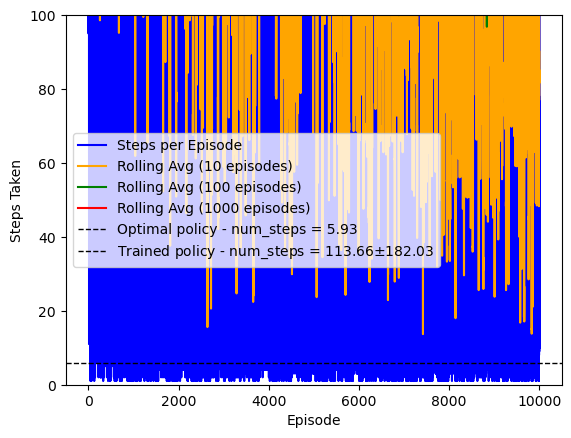

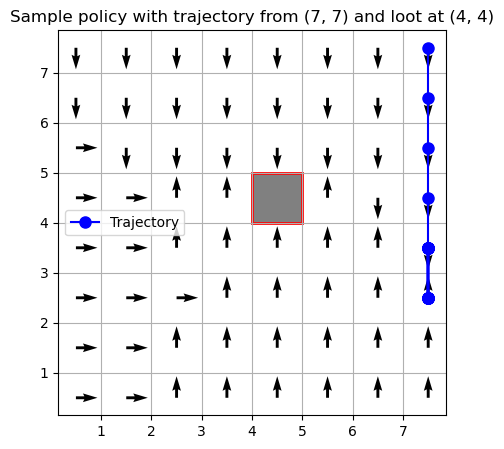

: 

In [ ]:
#Plotter
loot_x, loot_y = 4, 4
start_x, start_y = 0, 0

#Q-Learning
#steps_per_episode_plotter(ql_steps_per_episode, 5.93)
#plot_q_matrix_with_trajectory_discrete(ql_q_matrix, loot_x, loot_y, 7, 7)

#DQN-Learning

steps_per_episode_plotter(dqn_num_steps, 5.93, legend=True)
dqn_q_matrix = generate_q_matrix(dqn_agent1, dqn_env)
plot_q_matrix_with_trajectory_discrete(dqn_q_matrix, loot_x, loot_y, 7, 7)

#PPO-Learning
#q_matrix_w_trajectory(ppo_env.unwrapped, model, quiver_grid_size=8, figsize=(6, 6), start_position=[start_x+0.5, start_y+0.5], loot_position=[loot_x+0.5, loot_y+0.5])
#steps_per_episode_plotter(ppo_num_steps, 4.66-0.5, legend=True) #REMOVE 0.5 FROM OPTIMAL POLICY SINCE THE GAME TERMINATES WHEN THE AGENT IS WITHIN 0.5 DISTANCE OF THE LOOT.



In [7]:
gridsizes = [5, 8, 10, 15, 20, 50, 100]


